In [4]:
# mobilenet_multiclass_clean.py
# Clean, ready-to-run MobileNetV2 multi-class training/eval/inference script.
# Expects original dataset layout: original_dataset/<glioma|meningioma|pituitary>/*.*
# Supports image files and preprocessed .npy arrays.

import os
import random
from typing import List, Tuple

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# -------------------------
# CONFIG
# -------------------------
ORIGINAL_DATASET = "/content/drive/MyDrive/MindScan/new_dataset"
CLASS_NAMES = ["glioma", "meningioma", "pituitary"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 20
BEST_MODEL_PATH = "best_mobilenetv2_multiclass.pth"
PATIENCE = 5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# UTIL: gather files, stratified split
# -------------------------
def gather_files(root: str, classes: List[str]) -> Tuple[List[str], List[int]]:
    paths, labels = [], []
    for i, cls in enumerate(classes):
        folder = os.path.join(root, cls)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Class folder not found: {folder}")
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".npy")):
                paths.append(os.path.join(folder, fname))
                labels.append(i)
    return paths, labels

all_paths, all_labels = gather_files(ORIGINAL_DATASET, CLASS_NAMES)

X_train, X_test_val, y_train, y_test_val = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.5, random_state=SEED, stratify=y_test_val
)

print(f"Train size: {len(X_train)}  Val size: {len(X_val)}  Test size: {len(X_test)}")

# -------------------------
# DATASET (handles .npy and images)
# -------------------------
class TumorTypeSplitDataset(Dataset):
    def __init__(self, paths: List[str], labels: List[int], transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def load_image(self, p: str) -> Image.Image:
        if p.lower().endswith(".npy"):
            arr = np.load(p)
            if arr.dtype != np.uint8:
                arr_u8 = np.clip((arr * 255.0), 0, 255).astype(np.uint8)
            else:
                arr_u8 = arr
            pil = Image.fromarray(arr_u8).convert("RGB")
            return pil
        else:
            return Image.open(p).convert("RGB")

    def __getitem__(self, idx):
        p = self.paths[idx]
        label = self.labels[idx]
        img = self.load_image(p)
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TRANSFORMS
# -------------------------
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = TumorTypeSplitDataset(X_train, y_train, transform=transform)
val_ds   = TumorTypeSplitDataset(X_val,   y_val,   transform=transform)
test_ds  = TumorTypeSplitDataset(X_test,  y_test,  transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# -------------------------
# MODEL: MobileNetV2 (fine-tune top)
# -------------------------
def create_mobilenetv2(num_classes: int):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    # freeze first feature blocks to reduce trainable params (tunable)
    for param in model.features[:7].parameters():
        param.requires_grad = False
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, num_classes)
    return model

model = create_mobilenetv2(len(CLASS_NAMES)).to(DEVICE)

# -------------------------
# LOSS, OPT, SCHEDULER
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

# -------------------------
# TRAIN / VALIDATE
# -------------------------
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Train Epoch {epoch}/{NUM_EPOCHS}", leave=False):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100.0 * correct / total
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.2f}%")

    # checkpoint + early stopping
    if val_loss + 1e-9 < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# -------------------------
# TEST EVALUATION & REPORT
# -------------------------
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix")
plt.show()

# -------------------------
# INFERENCE HELPER (single image) - uses preprocessing below
# -------------------------
def predict_image_model(model, img_path: str) -> str:
    model.eval()
    img_np = preprocess_image(img_path)  # returns grayscale numpy (H,W) normalized [0,1]
    if img_np is None:
        return "Error reading image"
    img = Image.fromarray((img_np * 255).astype(np.uint8)).convert("RGB")
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(inp)
        pred = out.argmax(dim=1).item()
    return CLASS_NAMES[pred]

# -------------------------
# PREPROCESSING FUNCTIONS (exactly as requested)
# -------------------------
def crop_black(img):
    """Crop black borders around the brain area."""
    coords = cv2.findNonZero(img)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

def preprocess_image(img_path, target_size=(224, 224)):
    """Full preprocessing pipeline for one image."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = crop_black(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.bilateralFilter(img, d=5, sigmaColor=20, sigmaSpace=50)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img


Train size: 3522  Val size: 755  Test size: 755


KeyboardInterrupt: 

Train size: 3522, Val size: 755, Test size: 755


Epoch 1: 100%|██████████| 111/111 [20:31<00:00, 11.10s/it]


Epoch 1/10 | Train Loss: 0.3021, Train Acc: 0.8861 | Val Loss: 0.1514, Val Acc: 0.9457


Epoch 2: 100%|██████████| 111/111 [00:17<00:00,  6.39it/s]


Epoch 2/10 | Train Loss: 0.0721, Train Acc: 0.9781 | Val Loss: 0.1195, Val Acc: 0.9589


...

Epoch 8/10 | Train Loss: 0.0189, Train Acc: 0.9943 | Val Loss: 0.0881, Val Acc: 0.9748


Epoch 9: 100%|██████████| 111/111 [00:17<00:00,  6.30it/s]


Epoch 9/10 | Train Loss: 0.0476, Train Acc: 0.9824 | Val Loss: 0.0815, Val Acc: 0.9722


Epoch 10: 100%|██████████| 111/111 [00:16<00:00,  6.69it/s]


Epoch 10/10 | Train Loss: 0.0371, Train Acc: 0.9886 | Val Loss: 0.1221, Val Acc: 0.9709

Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96       243
  meningioma       0.93      0.96      0.94       247
   pituitary       0.99      0.98      0.98       265

    accuracy                           0.96       755
   macro avg       0.96      0.96      0.96       755
weighted avg       0.96      0.96      0.96       755



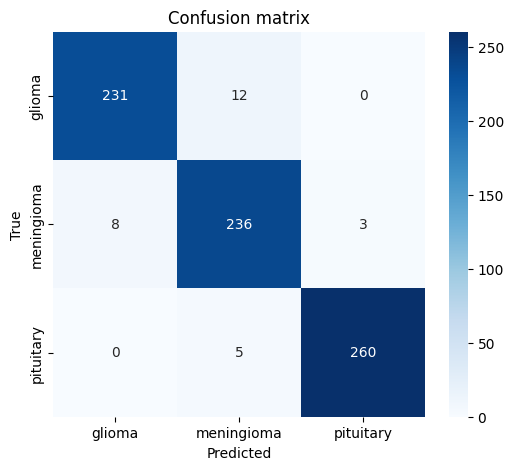

In [5]:
# mobilenet_multiclass.py
import os
import random
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from tqdm import trange, tqdm
import cv2

# -------------------------
# 1️⃣ Paths / Config
# -------------------------
original_dataset = "/content/drive/MyDrive/MindScan/new_dataset"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_WORKERS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 10
PATIENCE = 5
BEST_MODEL_PATH = "best_mobilenetv2_multiclass.pth"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ["glioma", "meningioma", "pituitary"]

# -------------------------
# 2️⃣ Gather file paths and stratified split
# -------------------------
def gather_files(root, classes):
    paths, labels = [], []
    for i, cls in enumerate(classes):
        folder = os.path.join(root, cls)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Class folder not found: {folder}")
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".npy")):
                paths.append(os.path.join(folder, fname))
                labels.append(i)
    return paths, labels

all_paths, all_labels = gather_files(original_dataset, CLASS_NAMES)

X_train, X_test_val, y_train, y_test_val = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.5, random_state=SEED, stratify=y_test_val
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

# -------------------------
# 3️⃣ Dataset class
# -------------------------
class TumorTypeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def load_image(self, p):
        if p.lower().endswith(".npy"):
            arr = np.load(p)
            if arr.dtype != np.uint8:
                arr_u8 = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
            else:
                arr_u8 = arr
            return Image.fromarray(arr_u8).convert("RGB")
        else:
            return Image.open(p).convert("RGB")

    def __getitem__(self, idx):
        img = self.load_image(self.paths[idx])
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# 4️⃣ Transforms
# -------------------------
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_ds = TumorTypeDataset(X_train, y_train, transform=transform)
val_ds   = TumorTypeDataset(X_val, y_val, transform=transform)
test_ds  = TumorTypeDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# -------------------------
# 5️⃣ MobileNetV2
# -------------------------
def create_mobilenetv2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    # Freeze first feature blocks to reduce trainable parameters
    for param in model.features[:7].parameters():
        param.requires_grad = False
    in_f = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_f, num_classes)
    return model

model = create_mobilenetv2(len(CLASS_NAMES)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# -------------------------
# 6️⃣ Training loop
# -------------------------
best_val_acc = 0
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, labels_batch = imgs.to(DEVICE), labels_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs, labels_batch = imgs.to(DEVICE), labels_batch.to(DEVICE)
            outputs = model(imgs)
            loss_val = criterion(outputs, labels_batch)
            val_loss_total += loss_val.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# -------------------------
# 7️⃣ Test evaluation
# -------------------------
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels_batch in test_loader:
        imgs, labels_batch = imgs.to(DEVICE), labels_batch.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.show()

# -------------------------
# 8️⃣ Inference helper
# -------------------------
def predict_image_model(model, img_path: str) -> str:
    model.eval()
    img_np = preprocess_image(img_path)
    if img_np is None:
        return "Error reading image"
    img = Image.fromarray((img_np * 255).astype(np.uint8)).convert("RGB")
    inp = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(inp)
        pred = out.argmax(dim=1).item()
    return CLASS_NAMES[pred]

# -------------------------
# 9️⃣ Preprocessing functions
# -------------------------
def crop_black(img):
    coords = cv2.findNonZero(img)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

def preprocess_image(img_path, target_size=(224,224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = crop_black(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.bilateralFilter(img, d=5, sigmaColor=20, sigmaSpace=50)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return img


In [12]:
# -------------------------
# 9️⃣ Test on a single image
# -------------------------

from PIL import Image
import torch

def predict_multiclass_image(model, img_path, transform, device, class_names):
    """
    Predict the tumor class for a single image using a trained multi-class model.

    Args:
        model : trained PyTorch model
        img_path : str, path to the image file
        transform : torchvision transform applied during training
        device : torch.device ("cuda" or "cpu")
        class_names : list of class names, e.g., ["glioma", "meningioma", "pituitary"]

    Returns:
        str: predicted class name
    """
    model.eval()

    img_np = preprocess_image(img_path)  # your preprocessing pipeline
    if img_np is None:
        return "Error reading image"

    # Convert grayscale NumPy array to RGB PIL image
    img = Image.fromarray((img_np * 255).astype(np.uint8)).convert("RGB")

    # Apply transform and move to device
    inp = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(inp)
        pred_class_idx = torch.argmax(output, dim=1).item()

    return class_names[pred_class_idx]


# Example usage
img_paths = [
    "/content/meningioma_1.webp",
    "/content/meningioma_2.webp",
    "/content/normal_1.webp",
    "/content/pituitary_1.webp",
    "/content/normal_2.webp"

]

for p in img_paths:
    print(f"Image {p} predicted class:", predict_multiclass_image(model, p, transform, device, CLASS_NAMES))



Image /content/meningioma_1.webp predicted class: meningioma
Image /content/meningioma_2.webp predicted class: meningioma
Image /content/normal_1.webp predicted class: meningioma
Image /content/pituitary_1.webp predicted class: meningioma
Image /content/normal_2.webp predicted class: meningioma
